In [1]:
# === Imports pour l'analyse exploratoire ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# Configuration pandas
pd.set_option('display.max_columns', None)

# Chemins
DATA_CLEAN = '../data/clean/'

# Chargement des datasets nettoyés
df_full = pd.read_csv(DATA_CLEAN + 'imdb_5000_clean.csv')
df_enriched = pd.read_csv(DATA_CLEAN + 'imdb_1000_enriched.csv')

print(f"Dataset complet : {df_full.shape[0]} films, {df_full.shape[1]} colonnes")
print(f"Dataset enrichi : {df_enriched.shape[0]} films, {df_enriched.shape[1]} colonnes")

Dataset complet : 4813 films, 33 colonnes
Dataset enrichi : 1000 films, 51 colonnes


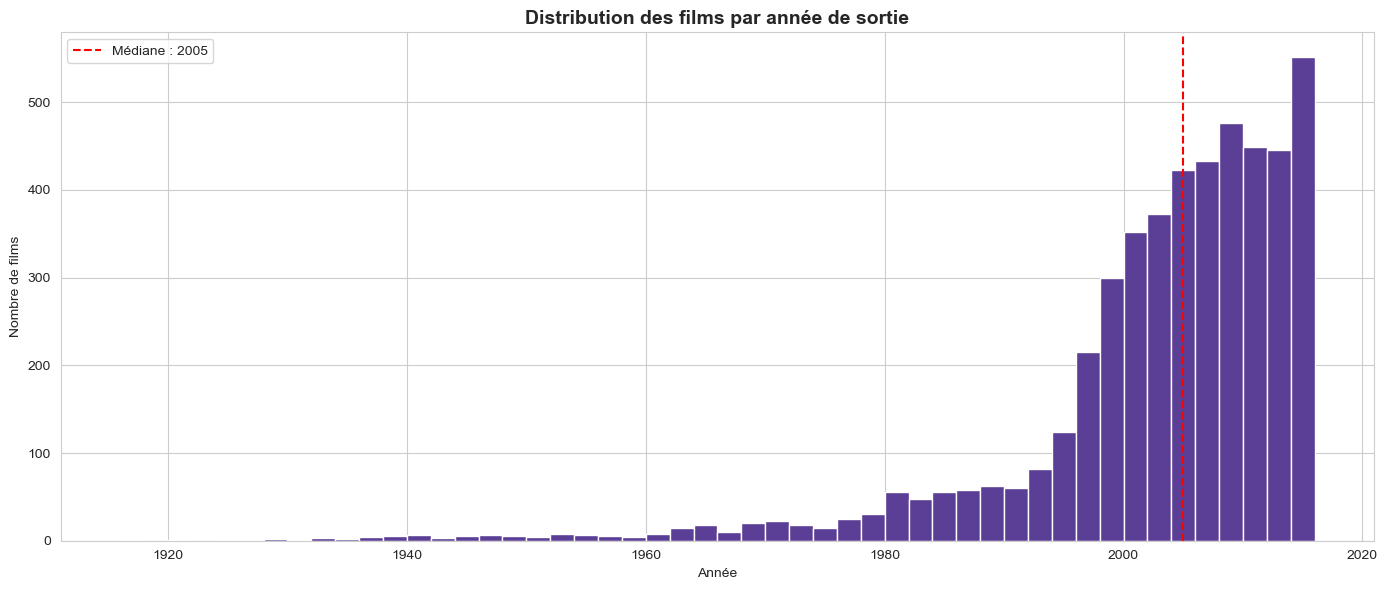

Année la plus ancienne : 1916
Année la plus récente : 2016
Année médiane : 2005
Année moyenne : 2002


In [2]:
# === Distribution des films par année ===

plt.figure(figsize=(14, 6))
plt.hist(df_full['title_year'], bins=50, color='#5B3E96', edgecolor='white')
plt.title('Distribution des films par année de sortie', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Nombre de films')
plt.axvline(df_full['title_year'].median(), color='red', linestyle='--', label=f"Médiane : {int(df_full['title_year'].median())}")
plt.legend()
plt.tight_layout()
plt.show()

# Quelques stats
print(f"Année la plus ancienne : {df_full['title_year'].min()}")
print(f"Année la plus récente : {df_full['title_year'].max()}")
print(f"Année médiane : {int(df_full['title_year'].median())}")
print(f"Année moyenne : {df_full['title_year'].mean():.0f}")

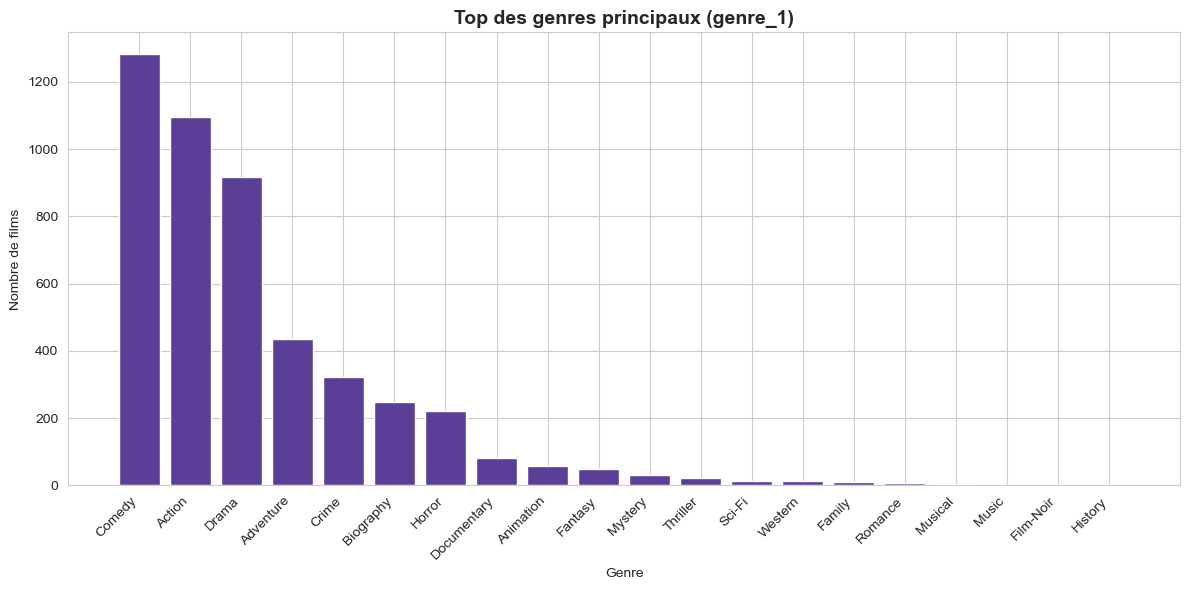

Classement complet :
genre_1
Comedy         1283
Action         1094
Drama           918
Adventure       436
Crime           323
Biography       249
Horror          221
Documentary      82
Animation        57
Fantasy          48
Mystery          32
Thriller         21
Sci-Fi           13
Western          12
Family           11
Romance           6
Musical           4
Music             1
Film-Noir         1
History           1
Name: count, dtype: int64


In [3]:
# === Top des genres principaux (genre_1) ===

# Comptage des genres principaux
top_genres = df_full['genre_1'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(top_genres.index, top_genres.values, color='#5B3E96', edgecolor='white')
plt.title('Top des genres principaux (genre_1)', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Nombre de films')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Classement complet :")
print(top_genres)

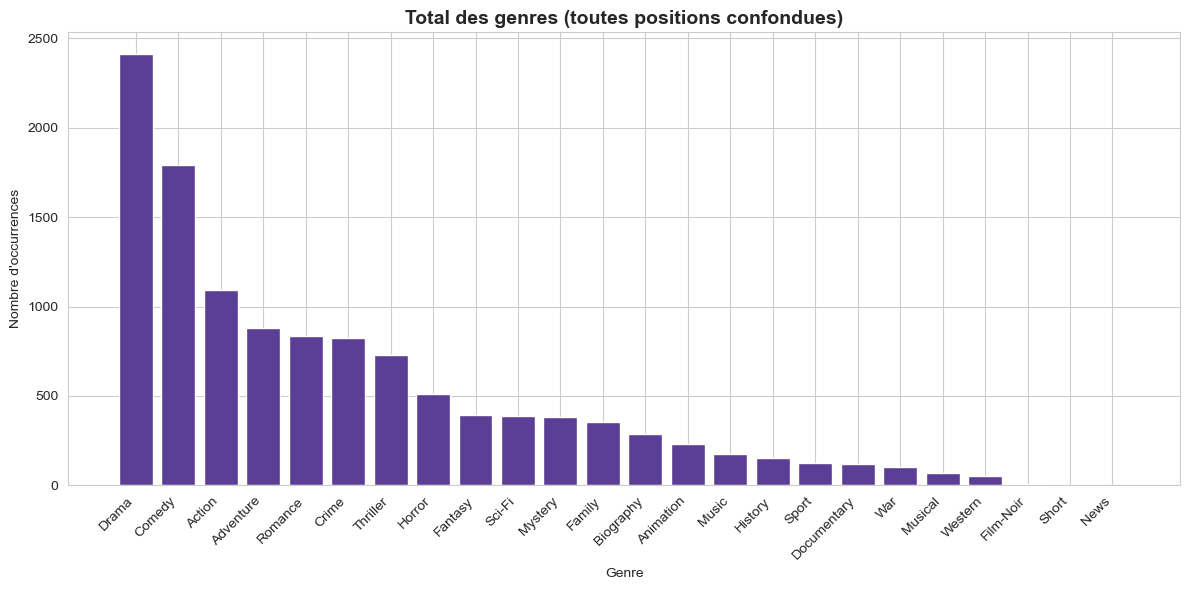

Top 10 des genres les plus fréquents :
Drama        2412
Comedy       1789
Action       1094
Adventure     878
Romance       833
Crime         823
Thriller      730
Horror        513
Fantasy       395
Sci-Fi        390
Name: count, dtype: int64


In [4]:
# === Comptage TOTAL des genres (genre_1 + genre_2 + genre_3) ===

# On concatène les 3 colonnes en une seule série
tous_genres = pd.concat([df_full['genre_1'], df_full['genre_2'], df_full['genre_3']])
genres_count = tous_genres.value_counts()

plt.figure(figsize=(12, 6))
plt.bar(genres_count.index, genres_count.values, color='#5B3E96', edgecolor='white')
plt.title('Total des genres (toutes positions confondues)', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Nombre d\'occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 des genres les plus fréquents :")
print(genres_count.head(10))

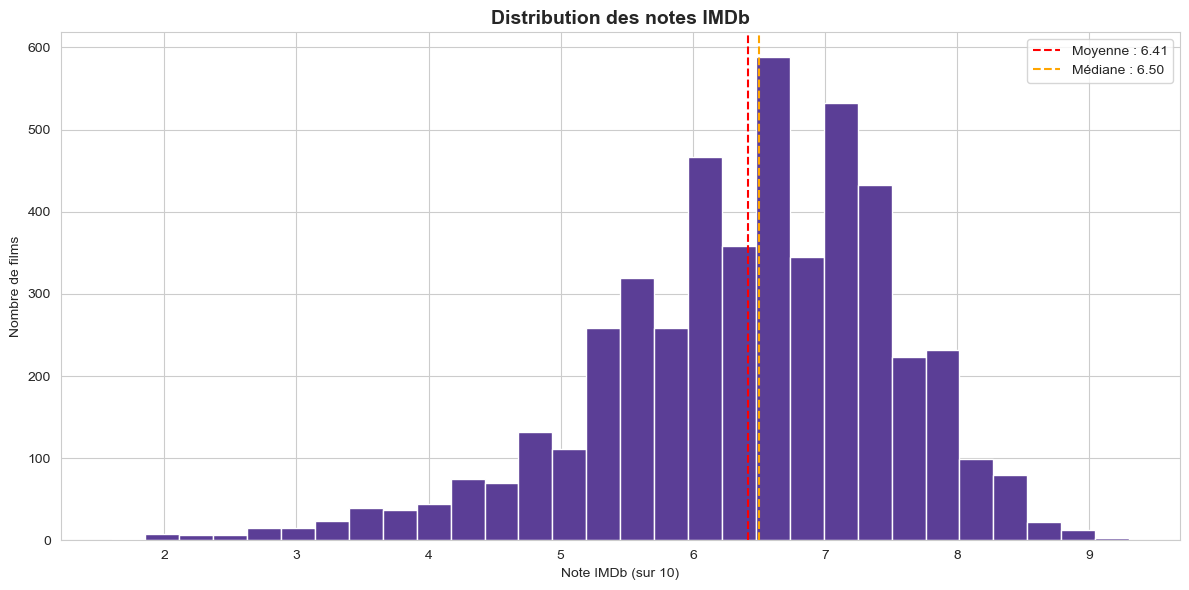

Note minimale : 1.6
Note maximale : 9.3
Note moyenne : 6.41
Note médiane : 6.50

Répartition par tranche :
  Excellents (8+) : 288 films (6.0%)
  Bons (7-8)      : 1348 films
  Moyens (6-7)    : 1759 films
  Faibles (<6)    : 1418 films


In [5]:
# === Distribution des notes IMDb ===

plt.figure(figsize=(12, 6))
plt.hist(df_full['imdb_score'], bins=30, color='#5B3E96', edgecolor='white')
plt.title('Distribution des notes IMDb', fontsize=14, fontweight='bold')
plt.xlabel('Note IMDb (sur 10)')
plt.ylabel('Nombre de films')
plt.axvline(df_full['imdb_score'].mean(), color='red', linestyle='--', 
            label=f"Moyenne : {df_full['imdb_score'].mean():.2f}")
plt.axvline(df_full['imdb_score'].median(), color='orange', linestyle='--', 
            label=f"Médiane : {df_full['imdb_score'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Note minimale : {df_full['imdb_score'].min()}")
print(f"Note maximale : {df_full['imdb_score'].max()}")
print(f"Note moyenne : {df_full['imdb_score'].mean():.2f}")
print(f"Note médiane : {df_full['imdb_score'].median():.2f}")
print(f"\nRépartition par tranche :")
print(f"  Excellents (8+) : {(df_full['imdb_score'] >= 8).sum()} films ({(df_full['imdb_score'] >= 8).sum()/len(df_full)*100:.1f}%)")
print(f"  Bons (7-8)      : {((df_full['imdb_score'] >= 7) & (df_full['imdb_score'] < 8)).sum()} films")
print(f"  Moyens (6-7)    : {((df_full['imdb_score'] >= 6) & (df_full['imdb_score'] < 7)).sum()} films")
print(f"  Faibles (<6)    : {(df_full['imdb_score'] < 6).sum()} films")

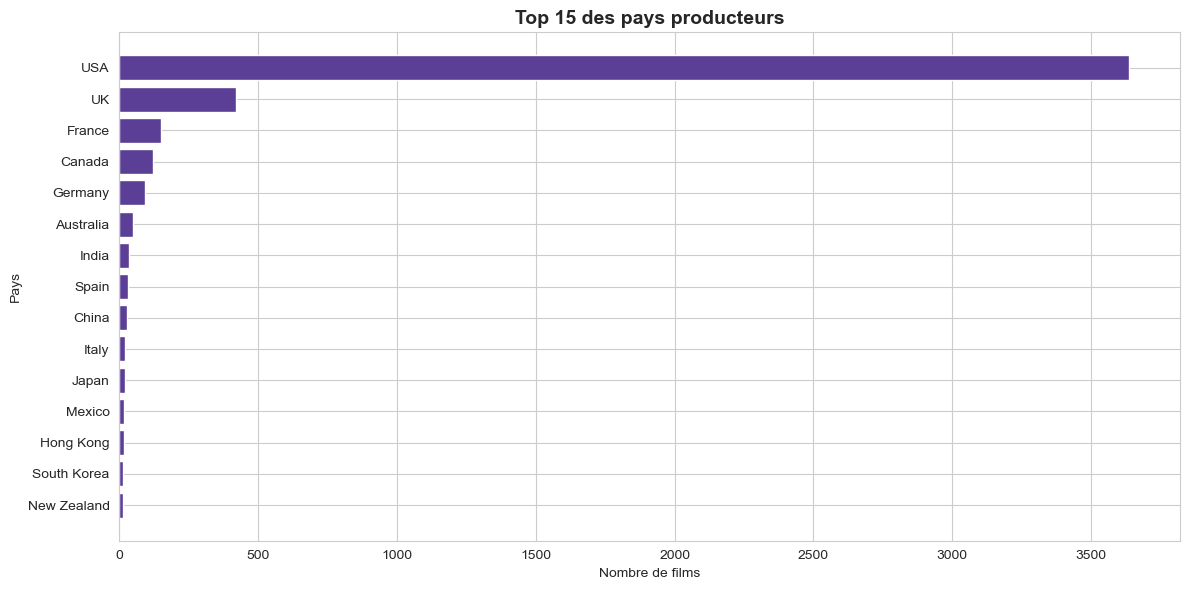

Top 15 :
country
USA            3638
UK              420
France          152
Canada          120
Germany          94
Australia        51
India            34
Spain            33
China            28
Italy            22
Japan            21
Mexico           17
Hong Kong        17
South Korea      14
New Zealand      13
Name: count, dtype: int64

Part des USA dans le dataset : 75.6%


In [6]:
# === Top 15 des pays producteurs ===

# La colonne 'country' existe dans le dataset complet
top_pays = df_full['country'].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_pays.index[::-1], top_pays.values[::-1], color='#5B3E96', edgecolor='white')
plt.title('Top 15 des pays producteurs', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de films')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

print("Top 15 :")
print(top_pays)

# Pourcentage des USA
pct_usa = (df_full['country'] == 'USA').sum() / df_full['country'].notna().sum() * 100
print(f"\nPart des USA dans le dataset : {pct_usa:.1f}%")

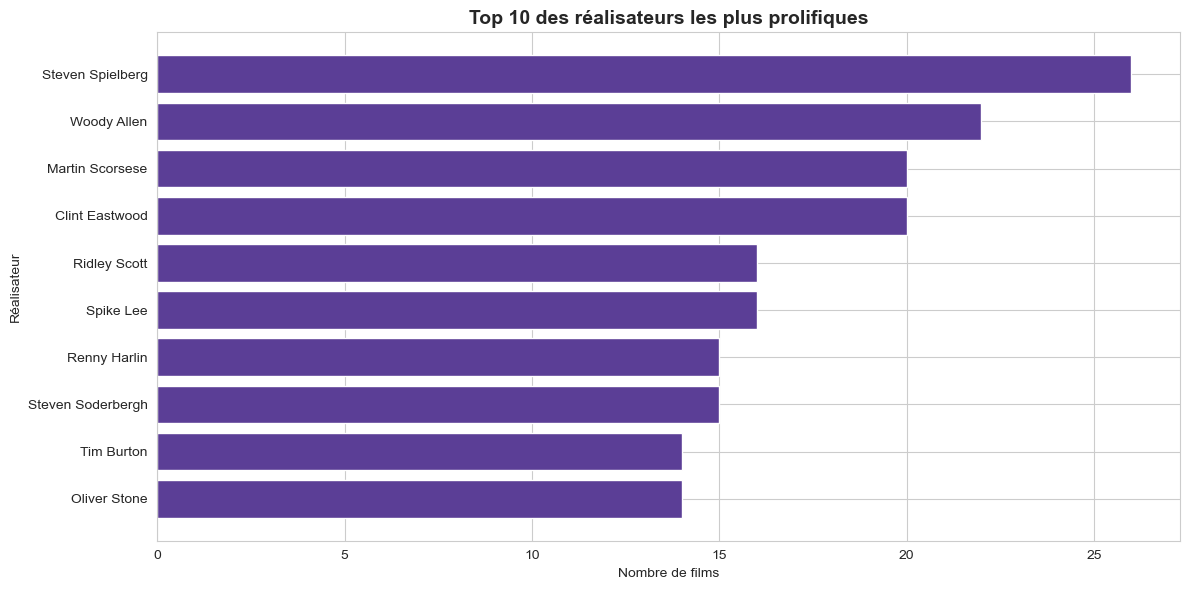

Top 10 réalisateurs :
director_name
Steven Spielberg     26
Woody Allen          22
Martin Scorsese      20
Clint Eastwood       20
Ridley Scott         16
Spike Lee            16
Renny Harlin         15
Steven Soderbergh    15
Tim Burton           14
Oliver Stone         14
Name: count, dtype: int64


In [7]:
# === Top 10 des réalisateurs les plus prolifiques ===

top_realisateurs = df_full['director_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_realisateurs.index[::-1], top_realisateurs.values[::-1], color='#5B3E96', edgecolor='white')
plt.title('Top 10 des réalisateurs les plus prolifiques', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de films')
plt.ylabel('Réalisateur')
plt.tight_layout()
plt.show()

print("Top 10 réalisateurs :")
print(top_realisateurs)

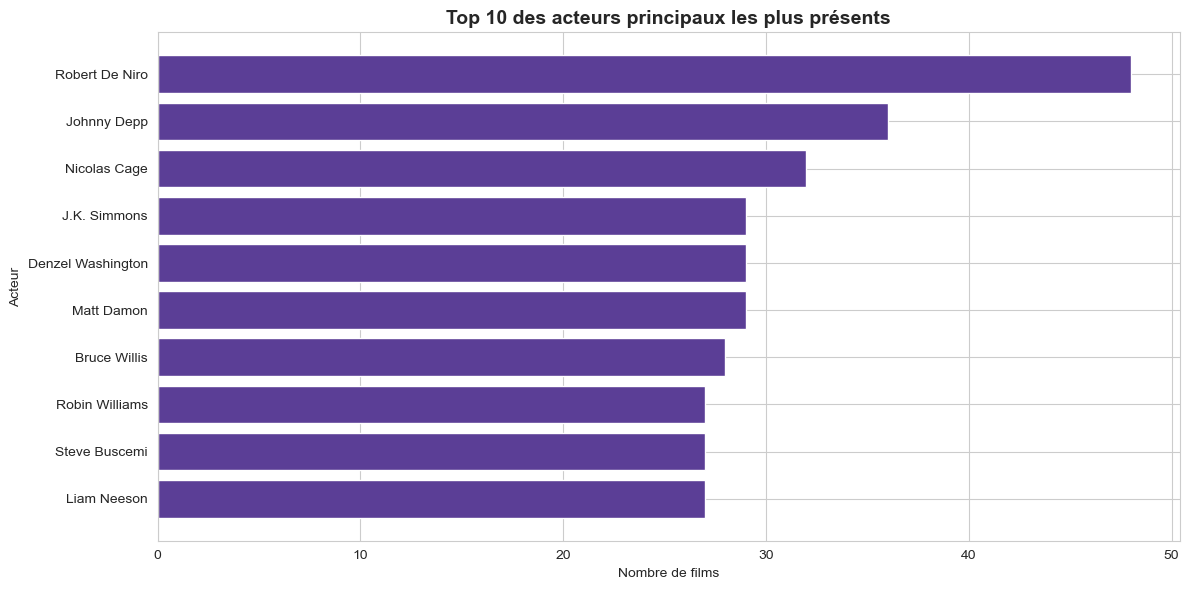

Top 10 acteurs principaux :
actor_1_name
Robert De Niro       48
Johnny Depp          36
Nicolas Cage         32
J.K. Simmons         29
Denzel Washington    29
Matt Damon           29
Bruce Willis         28
Robin Williams       27
Steve Buscemi        27
Liam Neeson          27
Name: count, dtype: int64


In [8]:
# === Top 10 des acteurs principaux les plus présents ===

top_acteurs = df_full['actor_1_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_acteurs.index[::-1], top_acteurs.values[::-1], color='#5B3E96', edgecolor='white')
plt.title('Top 10 des acteurs principaux les plus présents', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de films')
plt.ylabel('Acteur')
plt.tight_layout()
plt.show()

print("Top 10 acteurs principaux :")
print(top_acteurs)

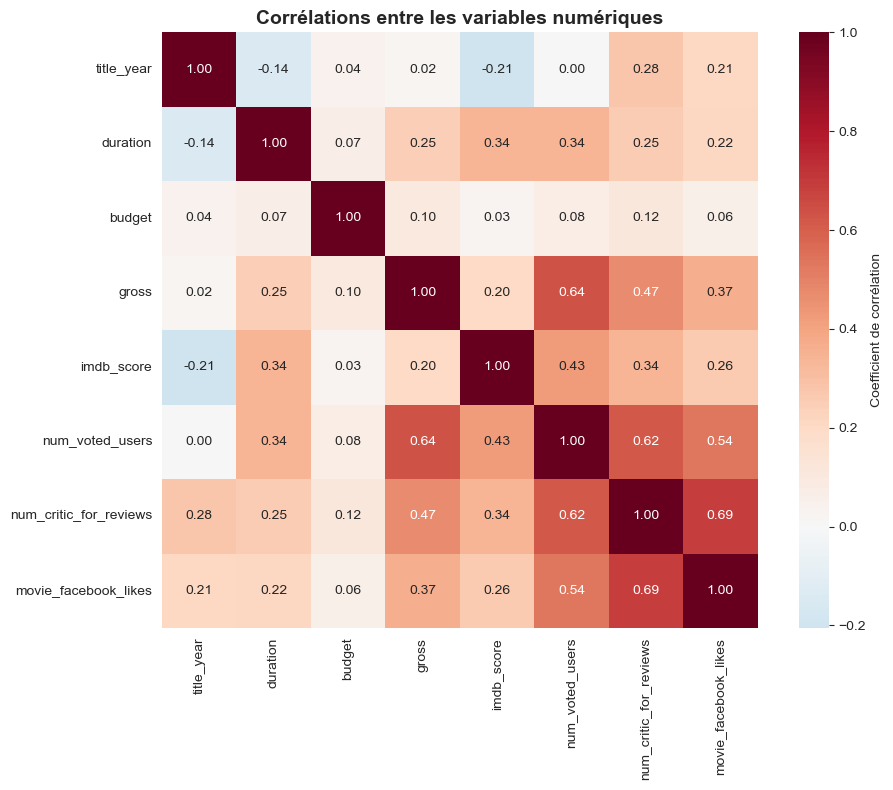

In [9]:
# === Heatmap des corrélations ===

# On sélectionne les variables numériques pertinentes
colonnes_num = ['title_year', 'duration', 'budget', 'gross', 'imdb_score', 
                'num_voted_users', 'num_critic_for_reviews', 'movie_facebook_likes']

# Calcul de la matrice de corrélation
corr_matrix = df_full[colonnes_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,           # afficher les valeurs
            fmt='.2f',            # 2 décimales
            cmap='RdBu_r',        # palette rouge-bleu
            center=0,             # 0 au centre
            square=True,          # cellules carrées
            cbar_kws={'label': 'Coefficient de corrélation'})
plt.title('Corrélations entre les variables numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

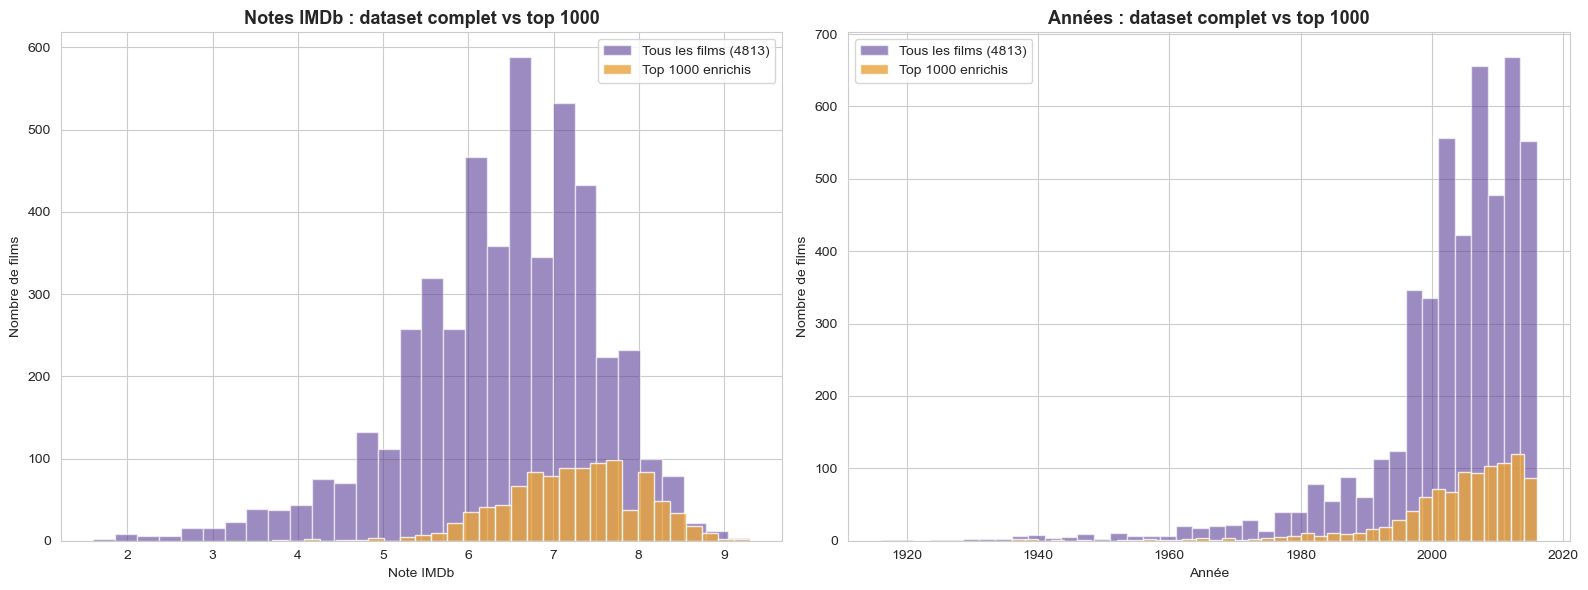

=== COMPARAISON DES DEUX DATASETS ===

Métrique                            Complet (4813)       Top 1000       
----------------------------------------------------------------------
Note IMDb moyenne                   6.41 / 10           7.24 / 10
Année médiane                       2005                2006
Durée moyenne (min)                 108                 121


In [10]:
# === Comparaison dataset complet vs dataset enrichi (1000 films cultes) ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : distribution des notes
axes[0].hist(df_full['imdb_score'], bins=30, color='#5B3E96', alpha=0.6, label='Tous les films (4813)', edgecolor='white')
axes[0].hist(df_enriched['imdb_score'], bins=30, color='#E8A33A', alpha=0.8, label='Top 1000 enrichis', edgecolor='white')
axes[0].set_title('Notes IMDb : dataset complet vs top 1000', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Note IMDb')
axes[0].set_ylabel('Nombre de films')
axes[0].legend()

# Graphique 2 : distribution par année
axes[1].hist(df_full['title_year'], bins=40, color='#5B3E96', alpha=0.6, label='Tous les films (4813)', edgecolor='white')
axes[1].hist(df_enriched['title_year'], bins=40, color='#E8A33A', alpha=0.8, label='Top 1000 enrichis', edgecolor='white')
axes[1].set_title('Années : dataset complet vs top 1000', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de films')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparaison des stats clés
print("=== COMPARAISON DES DEUX DATASETS ===\n")
print(f"{'Métrique':<35} {'Complet (4813)':<20} {'Top 1000':<15}")
print("-" * 70)
print(f"{'Note IMDb moyenne':<35} {df_full['imdb_score'].mean():.2f} / 10           {df_enriched['imdb_score'].mean():.2f} / 10")
print(f"{'Année médiane':<35} {int(df_full['title_year'].median())}                {int(df_enriched['title_year'].median())}")
print(f"{'Durée moyenne (min)':<35} {df_full['duration'].mean():.0f}                 {df_enriched['duration'].mean():.0f}")